# Fitz Nagumo System

## Generate Data & Fit Basis

#### Imports & Config

In [1]:
normalization = 1e-2

training_span = (0, 6) # (0, 6)
num_samples= 400 # 400
noiselevel= .01 # 0
num_regression_points= num_samples * 3 # 400
numPODmodes= 3 # 3
gp_regularizer= 1e-4 # 1e-4
ndraws=100 # 100
num_pulls = 200
exportto=None
openonsave=False
ddtdata=False

import numpy as np
import config
config.time_domain = np.linspace(0, 8, 801)  # Temporal domain t
import jax
rng_key = jax.random.PRNGKey(42)

time_domain_test = np.linspace(0, training_span[-1], num_regression_points)
time_domain_eval_training = np.linspace(0, training_span[-1], num_regression_points)

INFO:2025-10-21 15:04:36,829:jax._src.xla_bridge:822: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


Logging to log.log


In [2]:
import sys
sys.path.append("../things")
sys.path.append("helpers")
sys.path.append("../")

import os
import h5py
import numpy as np

import opinf

import utils
import step1_generate_data as step1

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation 
from IPython.display import HTML

### Generate & Visualize Data

In [3]:
if isinstance(numPODmodes, (list, tuple)) and len(numPODmodes) == 1:
    numPODmodes = numPODmodes[0]

# Report on experimental scenario.
utils.summarize_experiment(
    training_span=training_span,
    num_samples=num_samples,
    noiselevel=noiselevel,
    num_regression_points=num_regression_points,
    numPODmodes=numPODmodes,
    gp_regularizer=gp_regularizer,
    ndraws=ndraws,
)

# Step 1: Generate data ---------------------------------------------------
(
    model,
    time_domain,
    true_states,
    time_domain_sampled,
    snapshots_sampled,
) = step1.trajectory(training_span, num_samples, config, noiselevel)

time_domain_eval_prediction = np.linspace(0, time_domain[-1], int(num_regression_points/training_span[-1]*time_domain[-1]))
# time_domain_eval_prediction = np.linspace(0, time_domain[-1], num_regression_points)

time_domain.shape, true_states.shape, time_domain_sampled.shape, snapshots_sampled.shape


EXPERIMENTAL SCENARIO
Data: 400 uniformly sampled snapshots over 0.00 ≤ t < 6.00 with 1.00% noise
Dimension: retaining 3 POD modes
Training: using 1200 regression points
GP regularization: eta = 1.00e-04
Posterior: 100 draws

generating training data...done in 2.30 s.
done in 2.30 s.


((801,), (1024, 801), (400,), (1024, 400))

### Generate & Visualize Data

### Fit Basis

In [4]:
# Dimensionality reduction (POD).
with opinf.utils.TimedBlock(
    f"reducing noisy training states to {numPODmodes} dimensions"
):
    basis = config.Basis(num_vectors=numPODmodes)
    print(basis)
    print(f"Snapshot sampled shape: {snapshots_sampled.shape}")
    basis.fit(snapshots_sampled)
    # print(f"{}")
    snapshots_compressed = basis.compress(snapshots_sampled)
    full_states_compressed = basis.compress(true_states)
    print(full_states_compressed.shape)

reducing noisy training states to 3 dimensions...Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.14 s.
Basis
  full_state_dimension:    None
  reduced_state_dimension: None
  SVD solver: scipy.linalg.svd()
Snapshot sampled shape: (1024, 400)
(512, 400) (512, 400)
(3, 801)
done in 0.14 s.


### Create Data Scaler

In [5]:
import scaler
import importlib
importlib.reload(scaler)
from scaler import DataScaler

# Create and fit the scaler on training data
data_scaler = DataScaler(num_modes=numPODmodes)
data_scaler.fit(snapshots_compressed)

print(f"Scaler fitted:")
print(f"  Means: {data_scaler.means_.ravel()}")
print(f"  Stds: {data_scaler.stds_.ravel()}")

# Transform the data
snapshots_compressed_scaled = data_scaler.transform(snapshots_compressed)
full_states_compressed_scaled = data_scaler.transform(full_states_compressed)

print(f"\nOriginal data range: [{snapshots_compressed.min():.3f}, {snapshots_compressed.max():.3f}]")
print(f"Scaled data range: [{snapshots_compressed_scaled.min():.3f}, {snapshots_compressed_scaled.max():.3f}]")
print(f"Scaled data mean per mode: {snapshots_compressed_scaled.mean(axis=1)}")
print(f"Scaled data std per mode: {snapshots_compressed_scaled.std(axis=1)}")

Scaler fitted:
  Means: [11.46596079  0.46726743 -0.98557487]
  Stds: [12.0459715   1.98384082  1.61783417]

Original data range: [-3.926, 31.830]
Scaled data range: [-1.817, 2.874]
Scaled data mean per mode: [-1.24344979e-16  1.33226763e-17  0.00000000e+00]
Scaled data std per mode: [1. 1. 1.]


**Data Scaling Strategy:**

1. **Scaling**: Each POD mode is standardized independently: `x_scaled = (x - mean) / std`
2. **GP Fitting**: GPs are fitted on scaled data (variance priors centered at 1.0)
3. **Derivatives**: GP derivatives are computed in scaled space: `dx_scaled/dt = (dx/dt) / std`
4. **Operator Inference**: 
   - Sample latent states in scaled space
   - Convert to original space for operator application
   - Scale derivatives back: `d(x_scaled)/dt = f(x_original) / std`
5. **Visualization**: All plots show data in original (unscaled) space for interpretability

**Data Flow:**
```
Training Data (original) 
    ↓ [scale]
Training Data (scaled, mean≈0, std≈1)
    ↓ [GP fit]
GP Hyperparameters (for scaled data)
    ↓ [sample latent states]
X (in scaled space)
    ↓ [inverse transform]
X (in original space)
    ↓ [operator application]
dX/dt (in original space)
    ↓ [scale derivatives]
dX_scaled/dt (in scaled space)
    ↓ [match with GP derivatives]
Gradient Matching Constraint
```

This improves numerical stability and makes GP hyperparameter priors more intuitive.

#### Verify Scaling Operations

In [6]:
# Verify that scaling/unscaling is reversible
test_data = snapshots_compressed[:, :5]  # Take first 5 time points
scaled = data_scaler.transform(test_data)
unscaled = data_scaler.inverse_transform(scaled)

print("Scaling reversibility test:")
print(f"Max error: {np.abs(test_data - unscaled).max():.2e}")
print(f"Mean error: {np.abs(test_data - unscaled).mean():.2e}")
# assert np.allclose(test_data, unscaled, rtol=1e-6), "Scaling is not reversible!"

# Verify scaled data statistics
print(f"\nScaled data statistics:")
print(f"Mean per mode: {snapshots_compressed_scaled.mean(axis=1)}")
print(f"Std per mode: {snapshots_compressed_scaled.std(axis=1)}")
print(f"Expected: mean ≈ 0, std ≈ 1")

print("\n✅ Scaling verification passed!")

Scaling reversibility test:
Max error: 1.01e-06
Mean error: 2.46e-07

Scaled data statistics:
Mean per mode: [-1.24344979e-16  1.33226763e-17  0.00000000e+00]
Std per mode: [1. 1. 1.]
Expected: mean ≈ 0, std ≈ 1

✅ Scaling verification passed!


In [7]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

In [8]:
import numpy as np
import random
import time
import opinf
import os

### Generate Prior For operator matrix
input_func = config.ReducedOrderModel.input_func
inputs = input_func(time_domain_sampled) 
inputs_eval_time = input_func(time_domain_eval_training)

rom = opinf.ROM(
        basis=basis,
        ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_domain_sampled),
        model=JaxCompatibleModel(
            operators="cAHBN",
            solver=opinf.lstsq.L2Solver(regularizer=1e-4),
        ))

if os.path.exists("prior_ohat.npy"):
    print("Found prior operator matrix on disk, loading...")
    prior_ohat = np.load("prior_ohat.npy")
    print(prior_ohat)
    
    # Need to fit once to set up dimensions, then load our saved operator
    rom.fit(states=snapshots_sampled, inputs=inputs)
    rom.model._extract_operators(np.array(prior_ohat))
else:
    print("No saved operator found, computing new one...")
    rom.fit(states=snapshots_sampled, inputs=inputs)

    # Solve the ROM over a specified time domain. Make sure it's stable!
    Q_rom = rom.predict(snapshots_sampled[:, 0], time_domain, input_func=input_func)
    prior_ohat = rom.model.operator_matrix
    print(prior_ohat)
    
    # Verify stability before saving
    deter_pred = rom.model.predict(
        state0=snapshots_compressed[:, 0], 
        t=time_domain_sampled, 
        input_func=input_func
    )
    deter_sol = rom.model.predict_result_
    
    if deter_sol.t.shape[0] == snapshots_sampled.shape[1]:
        print('Found stable operator, saving to disk...')
        np.save("prior_ohat.npy", prior_ohat)
    else:
        print(f"Unstable operator! Got {deter_sol.t.shape[0]} timesteps, expected {snapshots_sampled.shape[1]}")
        print(deter_sol.t.shape[0], snapshots_compressed.shape, sep='\n')
        raise RuntimeError("Operator is unstable")

print("\nOperator loaded and ready to use.")

Found prior operator matrix on disk, loading...
[[ 6.26158887e+01 -6.18357523e+01 -5.79500723e+01  5.79156957e+01
   2.60385229e+00 -8.04939106e+00 -6.61939173e-01  4.14073221e+00
  -1.85883283e+00  2.36945366e+00  4.23744727e-02 -1.13586353e-02
   3.03759570e-01 -7.63355803e-02]
 [-4.09851254e+01 -1.83642681e+01 -4.74235438e+01 -3.27973368e+01
   8.84147529e-01 -1.82351676e+00 -5.89151951e+00  3.74886775e+00
  -1.27614759e+00  1.32125478e+00  2.29907684e+00 -9.79513945e-02
   4.80471552e-01 -2.70230854e-01]
 [ 1.22761023e+01  1.60635668e+01  2.58100334e+01  8.98429325e+00
  -7.00838930e-01  7.33431167e-01  1.52334195e-01 -4.66508370e-01
   8.42937539e-02  6.97178607e-02 -3.13766409e-01  2.64788099e-02
   4.09587216e-02 -1.42788341e-01]]
(512, 400) (512, 400)

Operator loaded and ready to use.

Operator loaded and ready to use.


## Run Model GP Model and Visualize Results

### Bayesian GP

#### Define and Run Model

In [9]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel

kernel = RBFKernel()

def model(
        time: jnp.array, 
        qhat: jnp.array,
        normalization=1e-8,  # Very small regularization
    ):
    num_time_steps = time.shape[0]
    
    # Get time scale
    time_range = time.max() - time.min()
    
    Ls = []
    Vars = []
    noises = []
    
    for i in range(numPODmodes):
        # For SCALED data, we expect variance ~ 1 and mean ~ 0
        # This makes the priors much more reasonable
        
        # Lengthscale prior (unchanged - this is in time units)
        lengthscale = numpyro.sample(f"lengthscale{i}", 
                                     dist.LogNormal(jnp.log(time_range/1e5), 1))
        Ls.append(lengthscale)
        
        # Variance prior for SCALED data (should be around 1)
        variance = numpyro.sample(f"variance{i}", 
                                 dist.LogNormal(0.0, 0.5))  # centered at 1.0
        Vars.append(variance)
        
        # Small noise since data looks clean
        noise = numpyro.sample(f"noise{i}", 
                              dist.LogNormal(-8.0, 1.0))  # Very small noise
        noises.append(noise)
        
        # Compute kernel matrix
        K = kernel(time, time, lengthscale, variance)
        
        # Add tiny regularization for numerical stability
        K_noise = K + (noise + normalization) * jnp.eye(num_time_steps)
        
        # GP prior
        x = numpyro.sample(f"f{i}", dist.MultivariateNormal(jnp.zeros(num_time_steps), K_noise))
        
        # Likelihood
        with numpyro.plate(f"data{i}", num_time_steps):
            numpyro.sample(f"y{i}", dist.Normal(x, jnp.sqrt(noise)), obs=qhat[i])

/home/anthonypoole/miniconda3/envs/prob-rom-inf/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Starting SVI optimization with SCALED data...
Iteration 0: loss = 2137191.5000
Iteration 0: loss = 2137191.5000
Iteration 100: loss = 257201.1406
Iteration 100: loss = 257201.1406
Iteration 200: loss = 63469.4688
Iteration 200: loss = 63469.4688
Iteration 300: loss = 16867.2012
Iteration 300: loss = 16867.2012
Iteration 400: loss = 2375.5520
Iteration 400: loss = 2375.5520
Early stopping at iteration 439

SVI completed after 440 iterations
Final loss: -7.1210
Early stopping at iteration 439

SVI completed after 440 iterations
Final loss: -7.1210


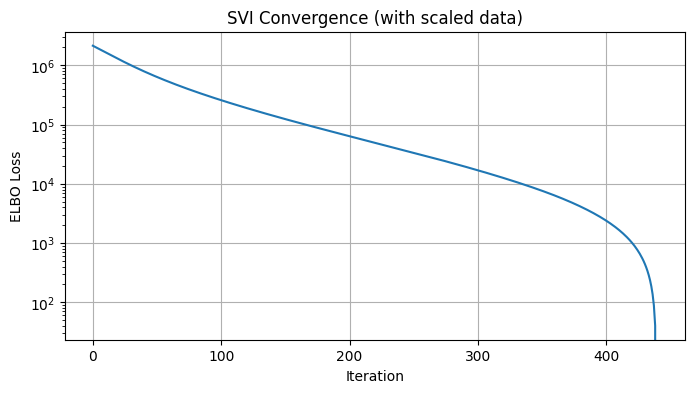

In [10]:
# Create autoguide
guide = autoguide.AutoDelta(model)
optimizer = Adam(step_size=0.01)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

# Use SCALED data for GP fitting
svi_state = svi.init(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed_scaled,  # <-- SCALED DATA
                     normalization=normalization
                     )

@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_sampled[:, None], 
                                  qhat=snapshots_compressed_scaled,  # <-- SCALED DATA
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 20000
losses = []
patience = 1000
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization with SCALED data...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if patience_counter > patience and i > 5000 or  loss < 0:
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples
predictive = Predictive(guide, params=params, num_samples=1000)
gp_samples = predictive(rng_key,
                     time=time_domain_sampled[:, None], 
                     qhat=snapshots_compressed_scaled,  # <-- SCALED DATA
                     normalization=normalization
                     )

print(f"\nSVI completed after {len(losses)} iterations")
print(f"Final loss: {losses[-1]:.4f}")

# Optional: Plot convergence
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence (with scaled data)')
plt.yscale('log')
plt.grid(True)
plt.show()

#### Visualize

Number of samples: 250


<Figure size 640x480 with 0 Axes>

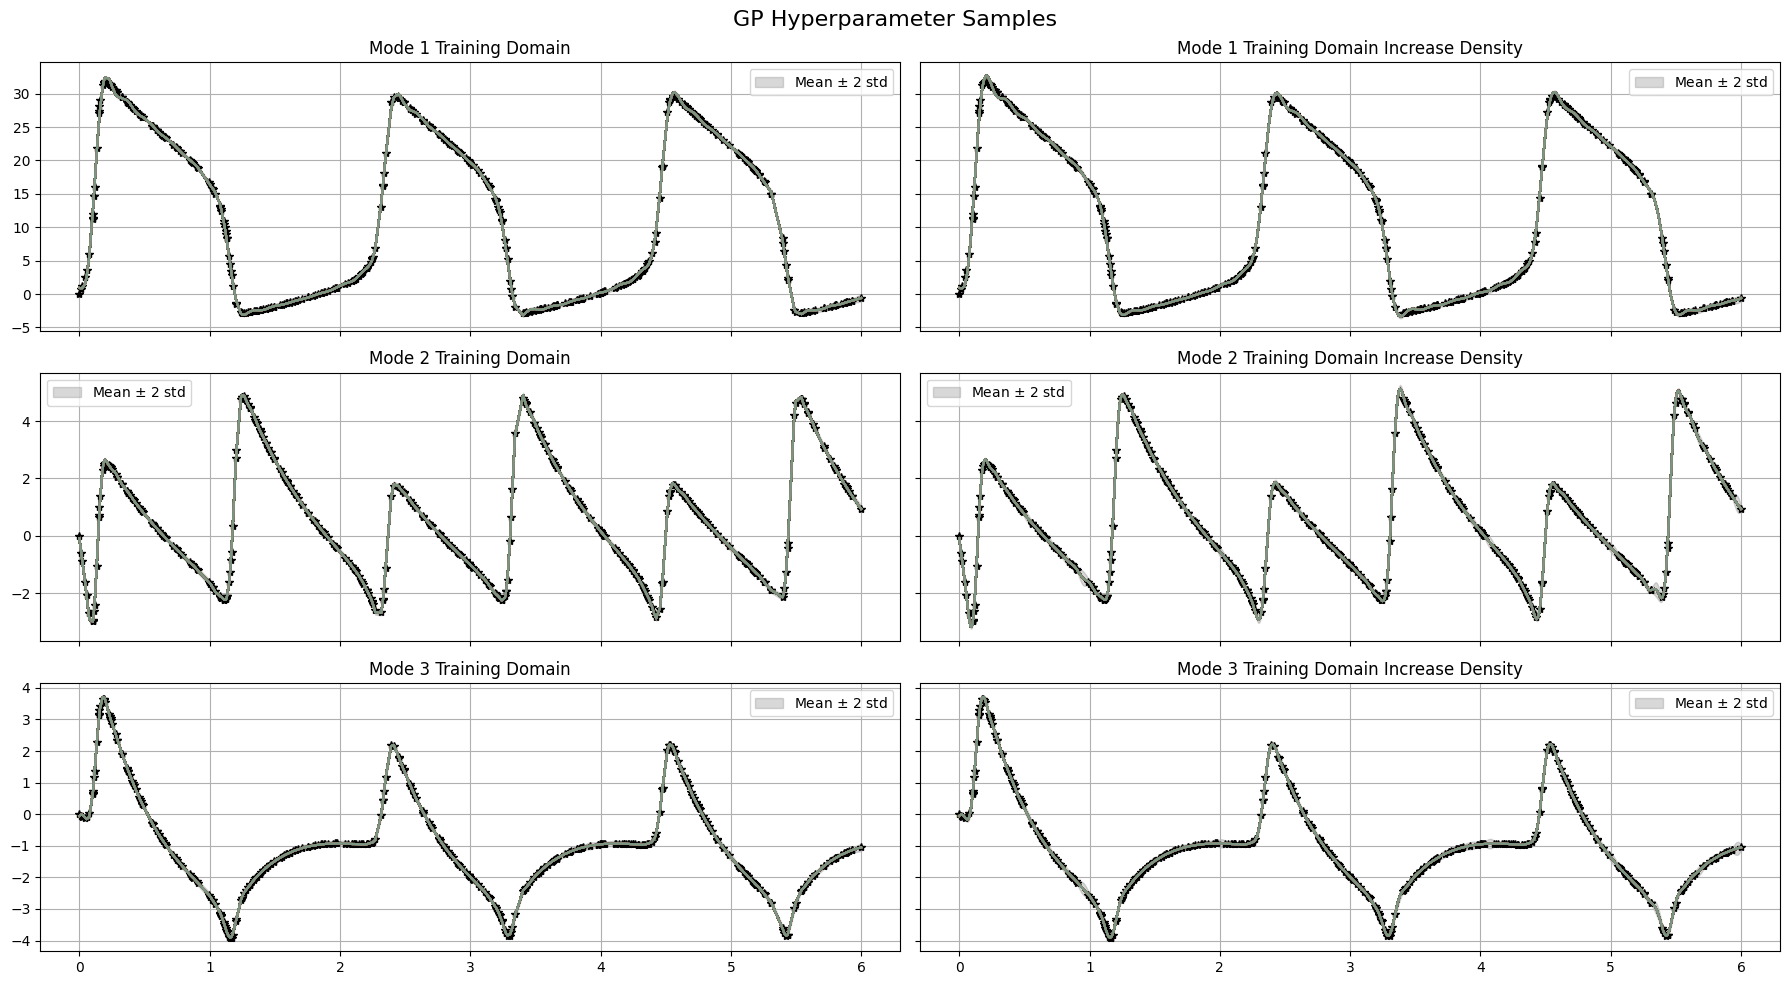

<Figure size 640x480 with 0 Axes>

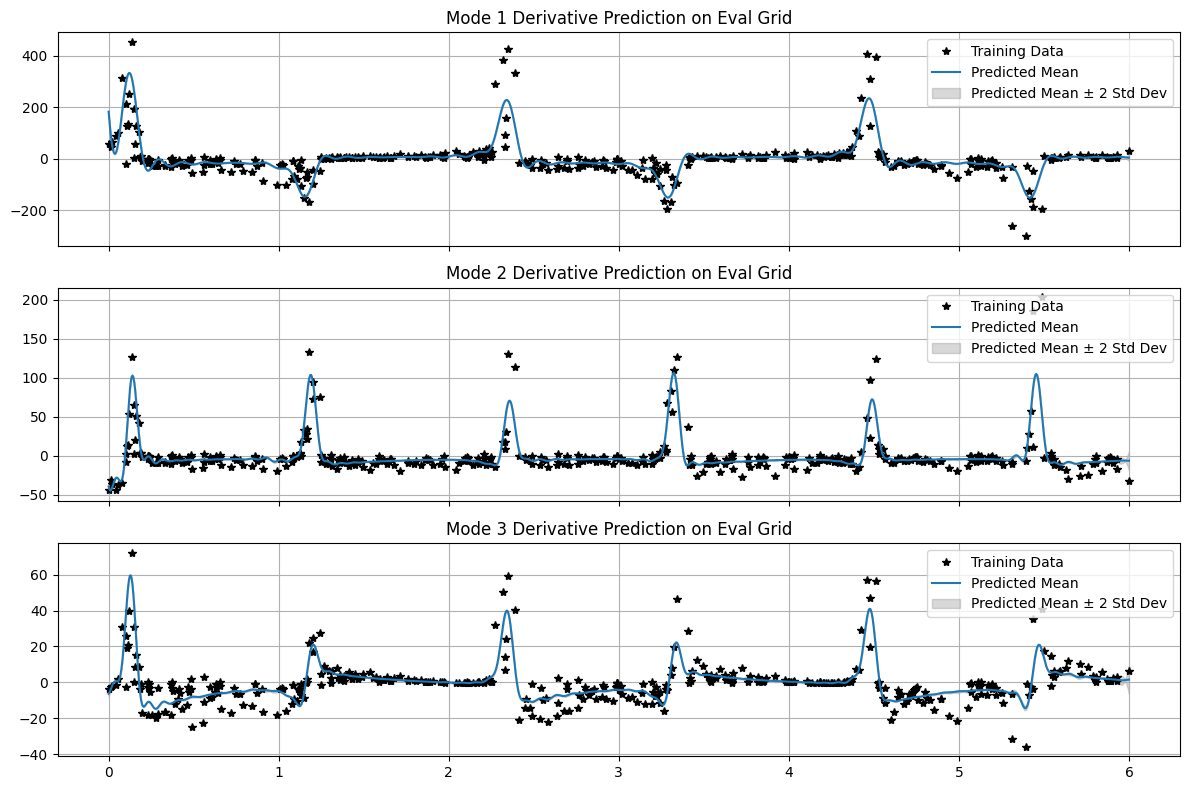

In [11]:
# Plot posterior samples
import fitz_plotter
import importlib
importlib.reload(fitz_plotter)

plotter = fitz_plotter.FitzPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed,  # Original unscaled data for plotting
            snapshots_prediction=full_states_compressed,  # Original unscaled data for plotting
            scaler=data_scaler  # <-- Pass the scaler
            )
plotter.gp_plot_state(
    lengthscales=[gp_samples[f'lengthscale{i}'] for i in range(numPODmodes)],
    variances=[gp_samples[f'variance{i}'] for i in range(numPODmodes)],
    noises=[gp_samples[f'noise{i}'] for i in range(numPODmodes)],
    max_num_samples=250,
    figsize=(18,10)
)
plt.show()
plotter.gp_plot_derivatives()
plt.show()

In [12]:
### Compute mean and std of each thing that we need (in SCALED space)

Ls_means = np.array([gp_samples[f'lengthscale{i}'].mean() for i in range(numPODmodes)])
Ls_stds = np.array([gp_samples[f'lengthscale{i}'].std() for i in range(numPODmodes)])
Ls_covs = np.array([jnp.cov(gp_samples[f'lengthscale{i}']) for i in range(numPODmodes)])
Vs_means = np.array([gp_samples[f'variance{i}'].mean() for i in range(numPODmodes)])
Vs_stds = np.array([gp_samples[f'variance{i}'].std() for i in range(numPODmodes)])
Vs_covs = np.array([jnp.cov(gp_samples[f'variance{i}']) for i in range(numPODmodes)])
Ns_means = np.array([gp_samples[f'noise{i}'].mean() for i in range(numPODmodes)])
Ns_stds = np.array([gp_samples[f'noise{i}'].std() for i in range(numPODmodes)])
Ns_covs = np.array([jnp.cov(gp_samples[f'noise{i}']) for i in range(numPODmodes)])
Fs_means = np.array([gp_samples[f'f{i}'].mean(axis=0) for i in range(numPODmodes)])

print("Hyperparameter statistics (for SCALED data):")
print(f"Lengthscale means: {Ls_means}")
print(f"Variance means: {Vs_means} (should be ~1 for scaled data)")
print(f"Noise means: {Ns_means}")

Ls_means.shape, Ls_stds.shape, Ls_covs.shape, Vs_means.shape, Vs_stds.shape, Vs_covs.shape, Ns_means.shape, Ns_stds.shape, Ns_covs.shape, Fs_means.shape

Hyperparameter statistics (for SCALED data):
Lengthscale means: [0.11501569 0.06385422 0.0666101 ]
Variance means: [0.48253134 0.51415706 0.40040964] (should be ~1 for scaled data)
Noise means: [0.00050175 0.00100824 0.0013705 ]


((3,), (3,), (3,), (3,), (3,), (3,), (3,), (3,), (3,), (3, 400))

In [13]:
### Plot gp predictions using SCALED data
from helpers.bgp_jax import BayesianGP

eval_points = [[] for i in range(numPODmodes)] 
eval_stds = [[] for i in range(numPODmodes)] 

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = []

for i in range(num_pulls):
    rand_idx = random.randint(0, len(gp_samples['lengthscale0']))
    Ls = np.array([gp_samples[f'lengthscale{i}'][rand_idx] for i in range(numPODmodes)])
    Vs = np.array([gp_samples[f'variance{i}'][rand_idx] for i in range(numPODmodes)])
    Ns = np.array([gp_samples[f'noise{i}'][rand_idx] for i in range(numPODmodes)])

    gp = BayesianGP()
    gp.X_train = time_domain_sampled[:, None]
    for j in range(numPODmodes):
        # Use SCALED data for GP predictions
        gp.y_train = snapshots_compressed_scaled[j]
        mean, std, _ = gp.predict_with_hypers(X_test=time_domain_sampled[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        mean_test, std_test, _ = gp.predict_with_hypers(X_test=time_domain_test[:, None], lengthscale=Ls[j], variance=Vs[j], noise=Ns[j])
        eval_points[j].append(mean_test)
        eval_stds[j].append(std_test)
        gp_samples[f'Xi{j}'].append(mean_test)

for i in range(numPODmodes):
    gp_samples[f'Xi{i}'] = np.array(gp_samples[f'Xi{i}'])

print("GP predictions computed in SCALED space")
print(f"Xi shape for mode 0: {gp_samples['Xi0'].shape}")

GP predictions computed in SCALED space
Xi shape for mode 0: (200, 1200)


### Given these latent states how do we compute $\dot{\tilde{x}}$

$[\tilde{x} \quad \dot{\tilde{x}}] \sim \mathcal{N}([0, 0], [[K^{yy} \quad K^{yz}], [K^{zy} \quad K^{zz}]])]$

In [14]:
def flatten_time(t: jnp.ndarray) -> jnp.ndarray:
    """Return t with shape (n,) no matter if (n,), (n,1) or (1,n) was given."""
    return jnp.ravel(t)

def rbf_eval(lengthscale: float, variance: float, t: jnp.ndarray, t2: jnp.ndarray) -> jnp.ndarray:
    """Full n×n RBF kernel matrix K_ij = variance * exp(-(t_i-t_j)^2 / (2*ell^2))."""
    t = flatten_time(t)
    t2 = flatten_time(t2)
    diff = t[:, None] - t2[None, :]
    ell2 = lengthscale ** 2
    return variance * jnp.exp(-diff**2 / (2.0 * ell2))

In [15]:
def joint_gp_derivatives(Ls, Vs, time1, time2):
    """
    Compute GP derivative mean and covariance.
    
    Works in SCALED space - returns derivatives of SCALED states.
    """
    K_yys = []
    K_zys = []
    K_zzs = []
    for i in range(numPODmodes):
        ell2 = Ls[i]**2
        
        # Standard RBF kernels
        rbf_yy = rbf_eval(Ls[i], Vs[i], time1, time1) 
        rbf_zy = rbf_eval(Ls[i], Vs[i], time2, time1)
        rbf_zz = rbf_eval(Ls[i], Vs[i], time2, time2)
        
        # K_yy with noise term
        K_yy = rbf_yy + 1e-5 * np.eye(len(time1))
        
        # K_zy: derivative kernel
        diff_zy = time2[:, None] - time1[None, :]
        K_zy = -(diff_zy / ell2) * rbf_zy
        
        # K_zz: second derivative kernel
        diff_zz = time2[:, None] - time2[None, :]
        K_zz = ((1 - (diff_zz**2 / ell2)) / ell2) * rbf_zz
        
        K_yys.append(K_yy)
        K_zys.append(K_zy)
        K_zzs.append(K_zz)

    # Prediction - using SCALED snapshots
    mu_z = []
    cov_z = []
    for i in range(numPODmodes):
        w = jnp.linalg.solve(K_yys[i], snapshots_compressed_scaled[i])  # <-- SCALED data
        mu_zi = K_zys[i] @ w
        mu_z.append(mu_zi)

        cov_zi = K_zzs[i] - K_zys[i] @ jnp.linalg.solve(K_yys[i], K_zys[i].T)
        cov_z.append(cov_zi)

    return jnp.array(mu_z), jnp.array(cov_z)

In [16]:
from jax.scipy.special import gammaln
import jax.numpy as jnp

def binom(x, y):
  return jnp.exp(gammaln(x + 1) - gammaln(y + 1) - gammaln(x - y + 1))

def Quadraticckron(state):
    return jnp.concatenate(
                [state[i] * state[: i + 1] for i in range(state.shape[0])],
                axis=0,
            )

def Cubicckron(state):
    state2 = Quadraticckron(state)
    lens = binom(jnp.arange(2, len(state) + 2), 2).astype(int)
    return jnp.concatenate(
        [state[i] * state2[: lens[i]] for i in range(state.shape[0])],
        axis=0,
    )

def khatri_rao(a, b):
    return jnp.vstack([jnp.kron(a[:, k], b[:, k]) for k in range(b.shape[1])]).T

class JaxCompatibleModel(opinf.models.ContinuousModel):
    def __init__(self, operators, solver=None, *args, **kwargs):
        super().__init__(operators, solver, *args, **kwargs)
    
    def _assemble_data_matrix(self, states, inputs):
        """Assemble the data matrix for operator inference."""
        blocks = []
        for i in self._indices_of_operators_to_infer:
            op = self.operators[i]
            if isinstance(op, opinf.operators.ConstantOperator):
                block = jnp.ones((1, jnp.atleast_1d(states).shape[-1]))
            elif isinstance(op, opinf.operators.LinearOperator):
                block = jnp.atleast_2d(states)
            elif isinstance(op, opinf.operators.QuadraticOperator):
                block = Quadraticckron(jnp.atleast_2d(states))
            elif isinstance(op, opinf.operators.CubicOperator):
                block =Cubicckron(np.atleast_2d(states))
            elif isinstance(op, opinf.operators.InputOperator):
                block =jnp.atleast_2d(inputs)
            elif isinstance(op, opinf.operators.StateInputOperator):
                block =khatri_rao(jnp.atleast_2d(inputs), jnp.atleast_2d(states))
            else:
                print("idkK!!", type(op))
            blocks.append(block.T)

        return jnp.hstack(blocks)

In [17]:
# Compute Xs means and covariances in SCALED space
Xs_means = np.stack(
    [gp_samples[f'Xi{i}'].mean(axis=0) for i in range(numPODmodes)],
    axis=0
)
Xs_covs = np.stack(
    [np.cov(gp_samples[f'Xi{i}'].T) for i in range(numPODmodes)],
    axis=0
)

print(f"Xs_means shape: {Xs_means.shape} (in SCALED space)")
print(f"Xs_covs shape: {Xs_covs.shape}")
print(f"Xs_means range: [{Xs_means.min():.3f}, {Xs_means.max():.3f}]")

def stable_cholesky(A, jitter=1e-6):
    """Compute Cholesky with automatic jitter for stability"""
    max_tries = 5
    for i in range(max_tries):
        try:
            L = jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))
            return L
        except:
            jitter *= 10
    return jnp.linalg.cholesky(A + jitter * jnp.eye(A.shape[0]))

def stable_solve(A, b, jitter=1e-6):
    """Solve linear system with regularization"""
    return jnp.linalg.solve(A + jitter * jnp.eye(A.shape[0]), b)

Xs_means shape: (3, 1200) (in SCALED space)
Xs_covs shape: (3, 1200, 1200)
Xs_means range: [-1.830, 2.904]


In [18]:
loaded_operator = rom.model.operator_matrix

In [69]:
import numpyro
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, autoguide, Predictive
from numpyro.optim import Adam
from helpers.bgp_jax import RBFKernel, get_c_phi, get_dash_c_phi, get_c_phi_dash, get_c_phi_double_dash 

kernel = RBFKernel()
importlib.reload(scaler)


def model(time, normalization=1e-6):
    """
    Gradient matching model that works in SCALED space.
    
    The key insight: if x_scaled = (x - mean) / std, then:
    dx_scaled/dt = (dx/dt) / std
    
    So we need to scale the operator's output appropriately.
    """
    num_time_steps = time.shape[0]
    gamma = 1e2
    # gamma = 5e2
    gamma = 1e-1

    min_std = 2e1
    factor  = 0.5

    # Sample operator in original (unscaled) space
    O = numpyro.sample(
        "O",
        dist.Normal(
            loc=jnp.zeros_like(loaded_operator),
            scale=gamma * jnp.ones_like(loaded_operator)
        )
    )

    Xs = []
    Ls = []
    Vars = []
    noises = []
    Kyys = []
    
    for i in range(numPODmodes):
        lengthscale = Ls_means[i]
        Ls.append(lengthscale)

        variance = Vs_means[i]
        Vars.append(variance)

        noise = Ns_means[i]
        noises.append(noise)

        Kyy = get_c_phi(lengthscale, variance, time, normalization)
        Kyys.append(Kyy)

        # Sample latent states in SCALED space
        Xs.append(
            numpyro.sample(
                f"X{i}",
                dist.MultivariateNormal(loc=Xs_means[i], covariance_matrix=Xs_covs[i]+normalization*jnp.eye(Xs_covs[i].shape[0])),
            )
        )
    
    # Compute f(X) = O @ phi(X) in SCALED space
    # First unscale X to original space
    Xs_orig = jnp.array([data_scaler.inverse_transform(jnp.array(Xs))[i] for i in range(numPODmodes)])
    
    # Compute dynamics in original space
    f_Xi_ohat_orig = rom.model._assemble_data_matrix(Xs_orig, inputs=inputs_eval_time) @ O.T
    
    # Scale the derivatives: d(x_scaled)/dt = (dx/dt) / std
    # f_Xi_ohat_scaled = jnp.array([f_Xi_ohat_orig.T[i] / data_scaler.stds_[i, 0] for i in range(numPODmodes)])

    # Get GP derivatives in SCALED space
    mu_z, cov_z = joint_gp_derivatives(Ls, Vars, time_domain_sampled, time)
    
    for i in range(numPODmodes):
        mu_zi = mu_z[i]
        cov_zi = cov_z[i]
        constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)

        numpyro.sample(
            f'ode_constraint{i}',
            dist.MultivariateNormal(mu_zi, constraint_cov),
            obs=f_Xi_ohat_orig.T[i]
            # obs=f_Xi_ohat_scaled[i]
        )

Starting SVI optimization...
Iteration 0: loss = 8474915.0000
Iteration 0: loss = 8474915.0000
Iteration 100: loss = 545891.0625
Iteration 100: loss = 545891.0625
Iteration 200: loss = 386482.9375
Iteration 200: loss = 386482.9375
Iteration 300: loss = 291678.2812
Iteration 300: loss = 291678.2812
Iteration 400: loss = 223950.1094
Iteration 400: loss = 223950.1094
Iteration 500: loss = 173842.6562
Iteration 500: loss = 173842.6562
Iteration 600: loss = 136279.3594
Iteration 600: loss = 136279.3594
Iteration 700: loss = 107585.7500
Iteration 700: loss = 107585.7500
Iteration 800: loss = 85230.3047
Iteration 800: loss = 85230.3047
Iteration 900: loss = 67551.8594
Iteration 900: loss = 67551.8594
Iteration 1000: loss = 53465.0078
Iteration 1000: loss = 53465.0078
Iteration 1100: loss = 42232.1523
Iteration 1100: loss = 42232.1523
Iteration 1200: loss = 33317.3047
Iteration 1200: loss = 33317.3047
Iteration 1300: loss = 26301.7910
Iteration 1300: loss = 26301.7910
Iteration 1400: loss = 20

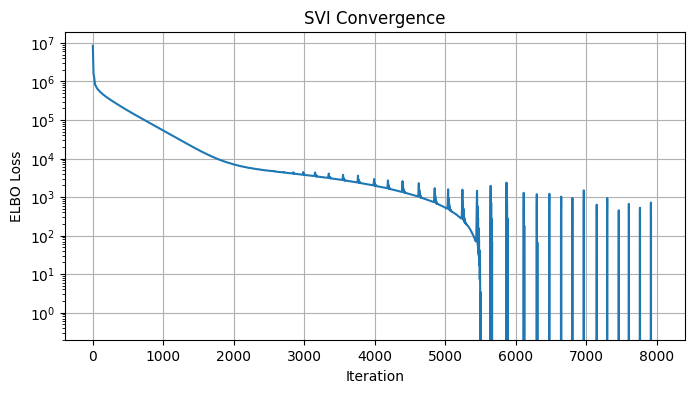

In [70]:
guide = autoguide.AutoDelta(model)

normalization = 1e-6

optimizer = Adam(step_size=0.005)
svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

svi_state = svi.init(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

# Training function
@jax.jit
def train_step(svi_state, rng_key):
    svi_state, loss = svi.update(svi_state, 
                                  time=time_domain_eval_training, 
                                  normalization=normalization
                                  )
    return svi_state, loss

num_iterations = 8000
losses = []
patience = 100
best_loss = float('inf')
patience_counter = 0

print("Starting SVI optimization...")
for i in range(num_iterations):
    rng_key, subkey = jax.random.split(rng_key)
    svi_state, loss = train_step(svi_state, subkey)
    losses.append(loss)
    
    # Early stopping with patience
    if loss < best_loss:
        best_loss = loss
        patience_counter = 0
    else:
        patience_counter += 1
    
    if (patience_counter > patience and i > 5000):
        print(f"Early stopping at iteration {i}")
        break
    
    if i % 100 == 0:
        print(f"Iteration {i}: loss = {loss:.4f}")

# Extract parameters from the trained guide
params = svi.get_params(svi_state)

# Get posterior samples if needed
predictive = Predictive(guide, params=params, num_samples=1000)
gm_samples = predictive(rng_key,
                     time=time_domain_eval_training, 
                     normalization=normalization
                     )

print(f"\nSVI completed after {num_iterations} iterations")
print(f"Final loss: {losses[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('ELBO Loss')
plt.title('SVI Convergence')
plt.yscale('log')
plt.grid(True)
plt.show()

In [71]:
# from numpyro.infer import MCMC, NUTS, init_to_value
# from numpyro.diagnostics import summary
# import jax.numpy as jnp
# import numpyro.distributions as dist
# import numpyro

# # Get initial values from your SVI/guide samples
# Omean = gm_samples['O'].mean(axis=0)
# Ostd = gm_samples['O'].std(axis=0)
# num_chains = 4
# numpyro.set_host_device_count(num_chains)

# def reparameterized_mcmc_model(time, gamma=5e-2, normalization=1e-6):
#     """
#     Reparameterized MCMC model using standardized coordinates.
#     This reduces correlations between parameters and improves geometry.
#     """
#     num_time_steps = time.shape[0]
    
#     # === REPARAMETERIZE O ===
#     # Instead of sampling O directly, sample a standardized version
#     # min_relative_std = 0.05
#     min_relative_std = .6 # 1
#     min_absolute_std = 1 # 2.
#     O_uncertainty = jnp.maximum(Ostd, jnp.maximum(min_relative_std * jnp.abs(Omean), min_absolute_std))
    
#     # Sample standardized O (zero mean, unit variance)
#     O_standardized = numpyro.sample('O_standardized', 
#                                     dist.Normal(jnp.zeros_like(Omean), 
#                                                jnp.ones_like(Omean)))
    
#     # Deterministically transform to actual O
#     # This makes O = Omean + O_uncertainty * O_standardized
#     O = numpyro.deterministic('O', Omean + O_uncertainty * O_standardized)
    
#     # === REPARAMETERIZE X VARIABLES ===
#     Xs = []
#     Xs_standardized = []
#     for i in range(numPODmodes):
#         # Compute Cholesky decomposition for numerical stability
#         X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
        
#         # Use Cholesky factorization for more stable sampling
#         try:
#             L = jnp.linalg.cholesky(X_cov)
#         except:
#             # If Cholesky fails, add more regularization
#             X_cov = Xs_covs[i] + (normalization * 10) * jnp.eye(Xs_covs[i].shape[0])
#             L = jnp.linalg.cholesky(X_cov)
        
#         # Sample standardized X (zero mean, unit variance)
#         X_std = numpyro.sample(
#             f"X{i}_standardized",
#             dist.Normal(jnp.zeros_like(Xs_means[i]), jnp.ones_like(Xs_means[i]))
#         )
#         Xs_standardized.append(X_std)
        
#         # Transform to actual X using Cholesky factor
#         X = numpyro.deterministic(f"X{i}", Xs_means[i] + L @ X_std)
#         Xs.append(X)
    
#     # === MODEL LIKELIHOOD (unchanged) ===
#     f_Xi_ohat = rom.model._assemble_data_matrix(Xs, inputs=None) @ O.T
#     mu_z, cov_z = joint_gp_derivatives(Ls_means, Vs_means, time_domain_sampled, time)
    
#     for i in range(numPODmodes):
#         mu_zi = mu_z[i]
#         cov_zi = cov_z[i]
#         constraint_cov = cov_zi + gamma * jnp.eye(num_time_steps)
        
#         numpyro.sample(
#             f'ode_constraint{i}',
#             dist.MultivariateNormal(mu_zi, constraint_cov),
#             obs=f_Xi_ohat.T[i]
#         )

# # === INITIALIZE WITH GOOD VALUES ===
# # Convert your MAP estimates to standardized space for initialization
# init_values_standardized = {
#     'O_standardized': jnp.zeros_like(Omean),  # Start at the mean
# }

# # # Initialize X in standardized space
# # for i in range(numPODmodes):
# #     if f'X{i}' in gm_samples:
# #         # If you have samples, convert them to standardized space
# #         X_cov = Xs_covs[i] + normalization * jnp.eye(Xs_covs[i].shape[0])
# #         try:
# #             L = jnp.linalg.cholesky(X_cov)
# #             L_inv = jnp.linalg.inv(L)
# #             X_centered = gm_samples[f'X{i}'].mean(axis=0) - Xs_means[i]
# #             init_values_standardized[f'X{i}_standardized'] = L_inv @ X_centered
# #         except:
# #             init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])
# #     else:
# #         init_values_standardized[f'X{i}_standardized'] = jnp.zeros_like(Xs_means[i])

# # === CONFIGURE STRUCTURED MASS MATRIX ===
# # Group correlated parameters together
# dense_mass_blocks = [
#     ("O_standardized",),  # O parameters are correlated within themselves
#     tuple([f"X{i}_standardized" for i in range(numPODmodes)])  # X parameters likely correlated
# ]

# # === RUN MCMC WITH IMPROVED SETTINGS ===
# print("Running MCMC with reparameterized model...")
# nuts_kernel = NUTS(
#     reparameterized_mcmc_model,
#     init_strategy=init_to_value(values=init_values_standardized),
#     # dense_mass=dense_mass_blocks,  # Use structured mass matrix
#     # max_tree_depth=12,  # Increase from default 10
#     target_accept_prob=0.9,  # Increase for better exploration in difficult geometries
# )

# mcmc = MCMC(
#     nuts_kernel,
#     num_warmup=150,  # Increase warm-up for better adaptation
#     num_samples=200,
#     num_chains=num_chains,
#     chain_method='parallel',
#     progress_bar=True,
# )

# # Run with moderate gamma first
# mcmc.run(
#     rng_key,
#     time=time_domain_eval_training,
#     gamma=1e3,  # You can adjust this
#     normalization=normalization,
# )

In [72]:
# # === CHECK DIAGNOSTICS ===
# def print_diagnostics(mcmc):
#     """Print detailed diagnostics for each parameter"""
#     samples = mcmc.get_samples(group_by_chain=True)
#     summary_dict = summary(samples)
    
#     print("\n" + "="*60)
#     print("MCMC Diagnostics Summary")
#     print("="*60)
    
#     # Separate standardized and deterministic variables
#     standardized_params = []
#     deterministic_params = []
#     constraint_params = []
    
#     for param in summary_dict.keys():
#         if '_standardized' in param:
#             standardized_params.append(param)
#         elif 'ode_constraint' in param:
#             constraint_params.append(param)
#         else:
#             deterministic_params.append(param)
    
#     # Print standardized parameters (these are what we actually sample)
#     if standardized_params:
#         print("\n📊 Standardized Parameters (key for convergence):")
#         print("-" * 50)
#         for param in sorted(standardized_params):
#             stats = summary_dict[param]
#             max_rhat = jnp.max(stats["r_hat"])
#             min_ess = jnp.min(stats["n_eff"])
            
#             if max_rhat > 1.01:
#                 status = "⚠️ "
#             else:
#                 status = "✅"
            
#             print(f"{status} {param:30s} r_hat={max_rhat:.4f}, min_ESS={min_ess:.0f}")
    
#     # Print deterministic transformations
#     if deterministic_params:
#         print("\n📈 Transformed Parameters:")
#         print("-" * 50)
#         for param in sorted(deterministic_params):
#             stats = summary_dict[param]
#             max_rhat = jnp.max(stats["r_hat"])
#             print(f"   {param:30s} r_hat={max_rhat:.4f}")
    
#     # Check for problems
#     problem_params = [p for p, s in summary_dict.items() 
#                      if jnp.max(s["r_hat"]) > 1.01 and '_standardized' in p]
    
#     if problem_params:
#         print(f"\n⚠️  Warning: {len(problem_params)} parameters have r_hat > 1.01")
#         print("Consider:")
#         print("  1. Increasing num_warmup and num_samples")
#         print("  2. Adjusting gamma (try values between 1e-2 and 1e-1)")
#         print("  3. Checking if normalization needs adjustment")
#     else:
#         print("\n✅ All parameters have converged well (r_hat ≤ 1.01)")
    
#     return summary_dict

# # Print diagnostics
# diagnostics = print_diagnostics(mcmc)

# # Get the final samples
# samples = mcmc.get_samples()
# print(f"\nSampling complete. Retrieved {len(samples['O'])} samples.")

In [73]:
samples = gm_samples

### Generate Predictions, Means, Medians and Percentiles via samples

Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping (3, 48)
Bad solve, skipping 

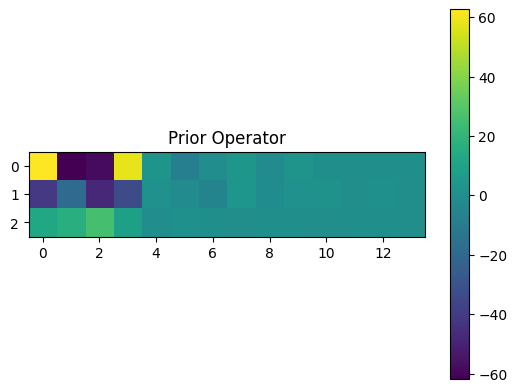

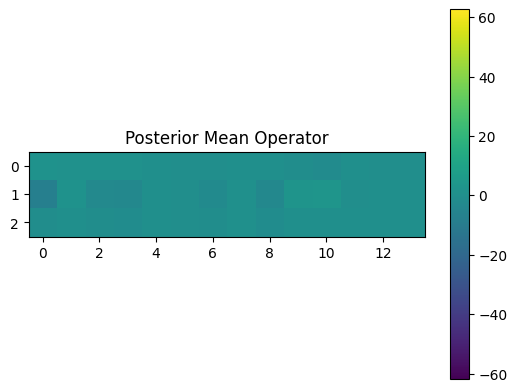

IndexError: index -1 is out of bounds for axis 0 with size 0

In [74]:
Os = []
Xs = []
Xs_orig = []  # Store original space X for ROM integration
rom_solves = []

for i in range(num_pulls):
    O = samples['O'][i]
    Os.append(O)
    
    # X samples are in SCALED space
    X_scaled = np.array([samples[f'X{j}'][i] for j in range(numPODmodes)])
    Xs.append(X_scaled)
    
    # Convert to original space for ROM prediction
    X_orig = data_scaler.inverse_transform(X_scaled)
    Xs_orig.append(X_orig)

    rom.model._extract_operators(np.array(O))
    
    # Use ORIGINAL space initial condition
    rom.model.predict(state0=snapshots_compressed[:, 0], t=time_domain_eval_training, input_func=input_func)
    if rom.model.predict_result_.y.shape[1] < time_domain_eval_training.size:
        print("Bad solve, skipping", rom.model.predict_result_.y.shape)
        continue
    rom_solves.append(rom.model.predict_result_.y)

Xs = np.array(Xs)  # Scaled space
Xs_orig = np.array(Xs_orig)  # Original space
Os = np.array(Os)
rom_solves = np.array(rom_solves)

print(f"Collected {len(rom_solves)} successful solves")
print(f"Xs shape (scaled): {Xs.shape}")
print(f"Xs_orig shape: {Xs_orig.shape}")

X_mean = Xs.mean(axis=0)
X_mean_orig = Xs_orig.mean(axis=0)
O_mean = Os.mean(axis=0)

plt.imshow(loaded_operator, vmin = min(loaded_operator.min(), O_mean.min()), vmax = max(loaded_operator.max(), O_mean.max()))
plt.colorbar()
plt.title("Prior Operator")
plt.show()
plt.imshow(O_mean, vmin = min(O_mean.min(), loaded_operator.min()), vmax = max(O_mean.max(), loaded_operator.max()))
plt.colorbar()
plt.title("Posterior Mean Operator")
plt.show()

rom_solves_mean = rom_solves.mean(axis=0)
X_median = np.median(Xs, axis=0)
X_median_orig = np.median(Xs_orig, axis=0)
O_median = np.median(Os, axis=0)
rom_solves_median = np.median(rom_solves, axis=0)
rom_solves_95 = np.percentile(rom_solves, 99, axis=0)
rom_solves_5 = np.percentile(rom_solves, 1, axis=0)

(1000, 3, 14) (1000, 3, 1200)


(1000, 3, 1200) (1000, 3, 1600)


<Figure size 640x480 with 0 Axes>

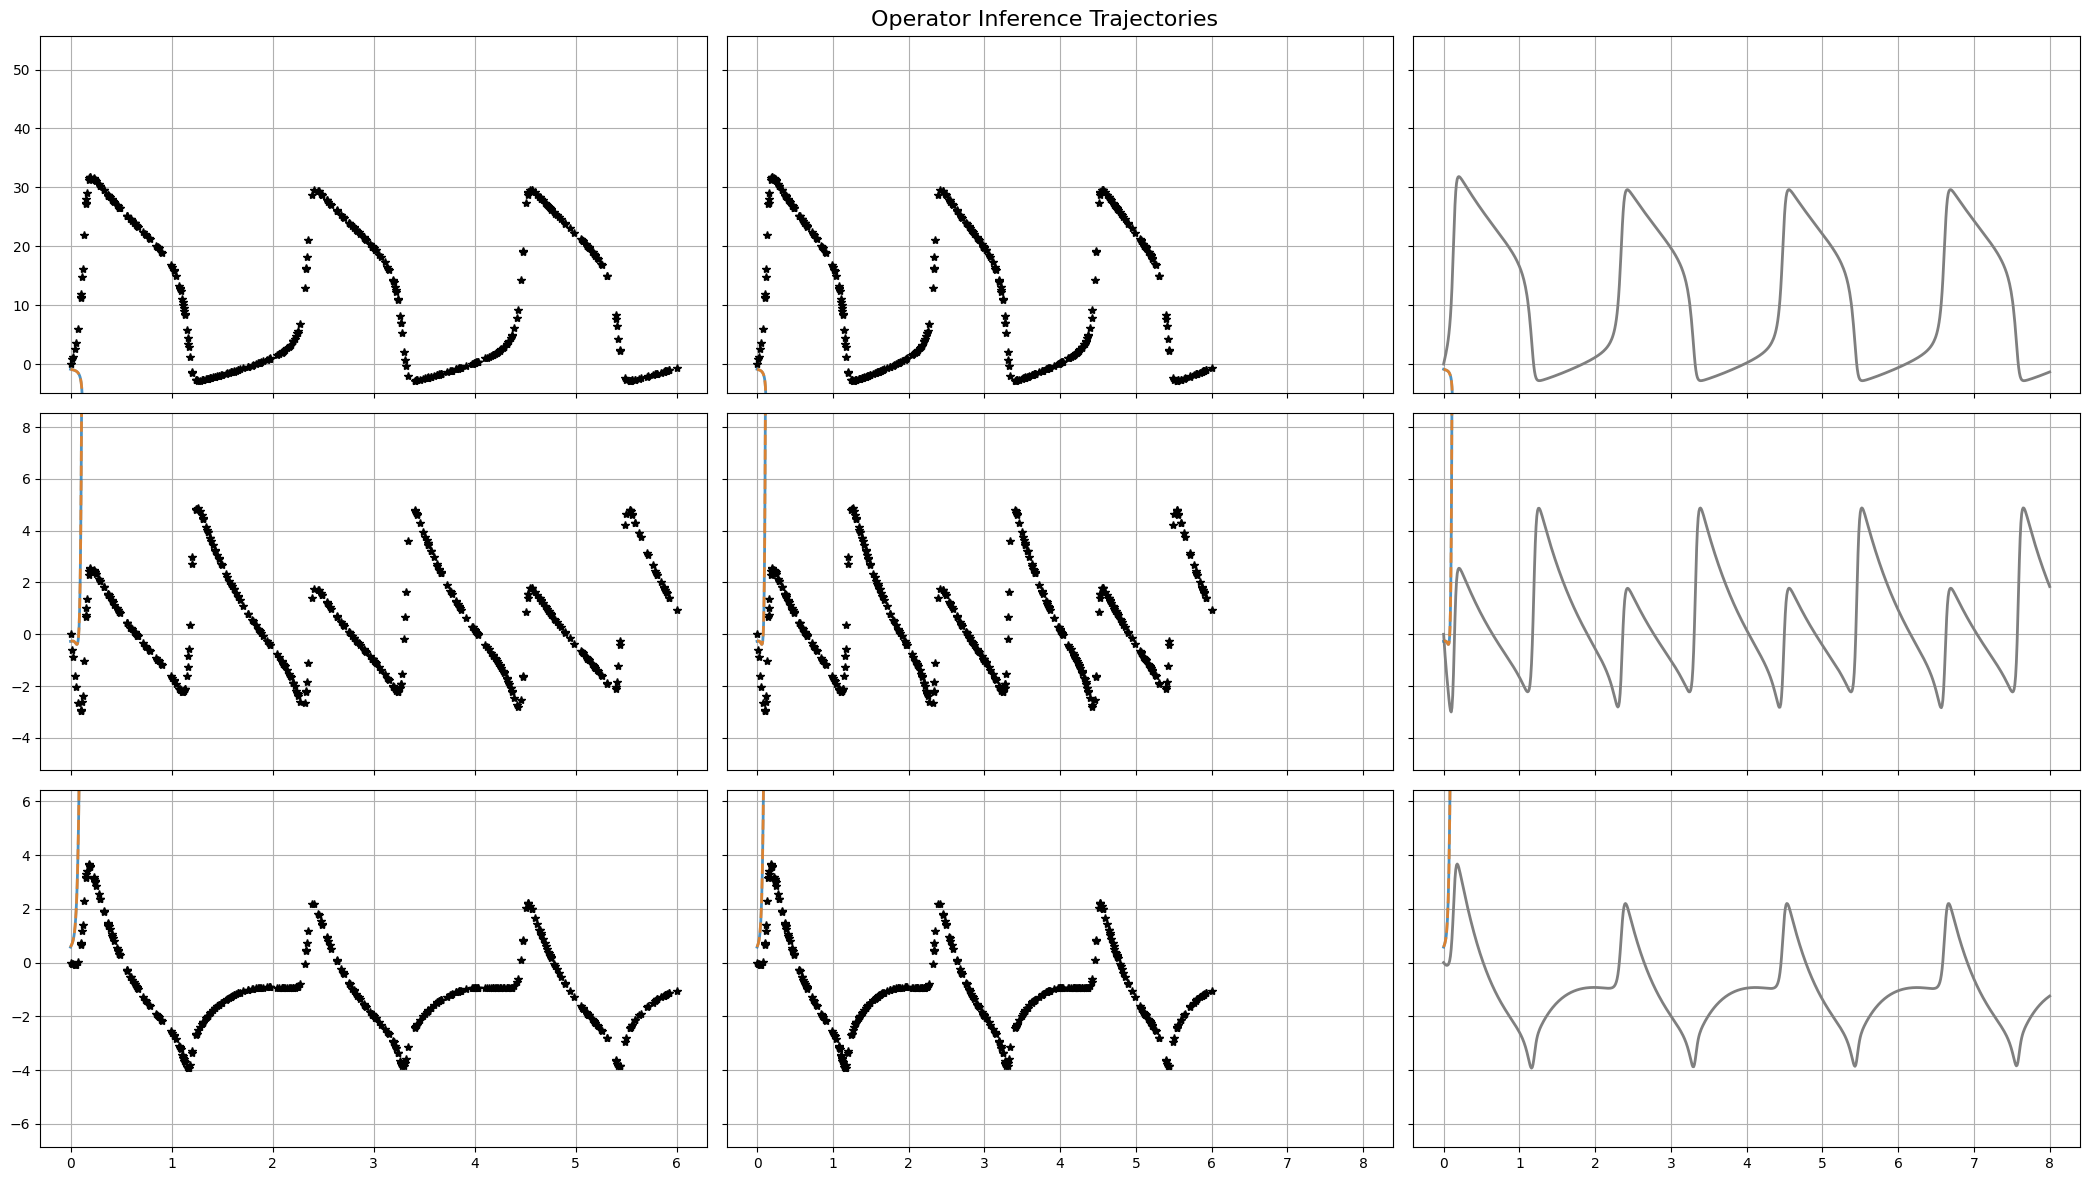

In [ ]:
# Plot posterior samples
import fitz_plotter
import importlib
importlib.reload(fitz_plotter)

plotter = fitz_plotter.FitzPlotter(
            numPODmodes=numPODmodes,
            time_domain_training=time_domain_sampled, 
            time_domain_prediction=time_domain, 
            time_domain_eval_training=time_domain_eval_training,
            time_domain_eval_prediction=time_domain_eval_prediction,
            snapshots_training=snapshots_compressed, 
            snapshots_prediction=full_states_compressed,
            )

plotter.operator_plot(
                    q0 = Xs_means[:, 0], 
                    operator_samples=samples['O'],
                    latent_state_samples=[samples[f'X{i}'] for i in range(numPODmodes)],
                    rom=rom,
                    input_func=input_func,
                    figsize=(21, 12),
                    max_num_samples=1000
)